device: cpu
train: 60000, test: 10000


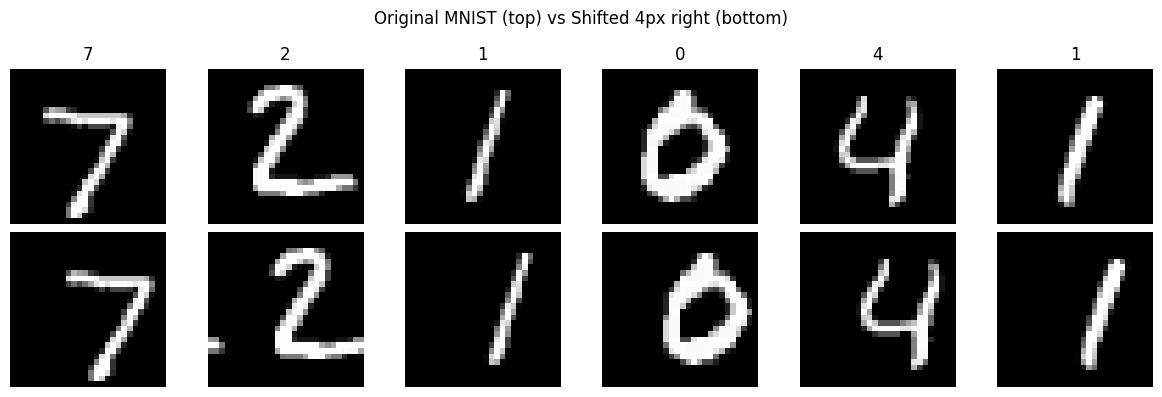

FCNN params: 569,226
CNN  params: 189,130
--- Training FCNN ---
ep 1/5 | loss 0.2944 | acc 91.72%
ep 2/5 | loss 0.1466 | acc 95.53%
ep 3/5 | loss 0.1180 | acc 96.39%
ep 4/5 | loss 0.1011 | acc 96.92%
ep 5/5 | loss 0.0885 | acc 97.20%

--- Training CNN ---
ep 1/5 | loss 0.1309 | acc 96.05%
ep 2/5 | loss 0.0464 | acc 98.57%
ep 3/5 | loss 0.0299 | acc 99.05%
ep 4/5 | loss 0.0209 | acc 99.30%
ep 5/5 | loss 0.0143 | acc 99.54%
Model      Original    Shifted     Drop
------------------------------------------
FCNN          98.07%     35.74%   62.33%
CNN           98.73%      61.63%   37.10%


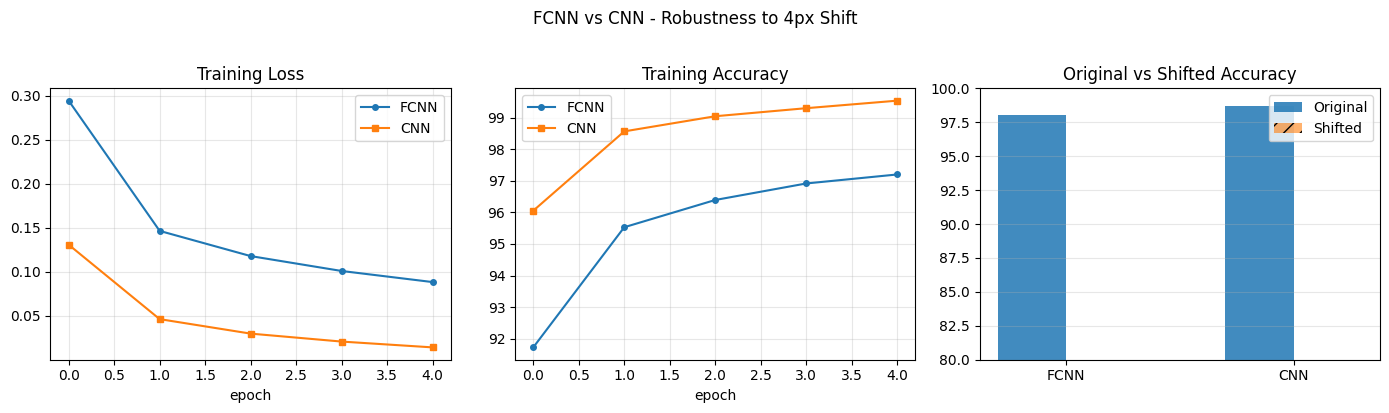

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
# normal transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# shifted transform - 4 pixels right
shift_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: torch.roll(x, shifts=4, dims=2))
])

train_data   = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data    = datasets.MNIST('./data', train=False, download=True, transform=transform)
shifted_test = datasets.MNIST('./data', train=False, download=True, transform=shift_transform)

train_loader        = DataLoader(train_data,    batch_size=64,  shuffle=True)
test_loader         = DataLoader(test_data,     batch_size=256, shuffle=False)
shifted_test_loader = DataLoader(shifted_test,  batch_size=256, shuffle=False)

print(f"train: {len(train_data)}, test: {len(test_data)}")

# visualize original vs shifted
orig_batch    = next(iter(test_loader))
shifted_batch = next(iter(shifted_test_loader))

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
fig.suptitle('Original MNIST (top) vs Shifted 4px right (bottom)')
for i in range(6):
    axes[0][i].imshow(orig_batch[0][i].squeeze(), cmap='gray')
    axes[0][i].set_title(orig_batch[1][i].item())
    axes[0][i].axis('off')
    axes[1][i].imshow(shifted_batch[0][i].squeeze(), cmap='gray')
    axes[1][i].axis('off')
plt.tight_layout()
plt.show()

# Model A - FCNN
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.fc1  = nn.Linear(28 * 28, 512)
        self.fc2  = nn.Linear(512, 256)
        self.fc3  = nn.Linear(256, 128)
        self.fc4  = nn.Linear(128, 10)
        self.bn1  = nn.BatchNorm1d(512)
        self.bn2  = nn.BatchNorm1d(256)
        self.bn3  = nn.BatchNorm1d(128)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        x = self.drop(F.relu(self.bn2(self.fc2(x))))
        x = self.drop(F.relu(self.bn3(self.fc3(x))))
        return self.fc4(x)


# Model B - 2 layer CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)   # 28->26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)  # 26->24
        self.fc    = nn.Linear(32 * 24 * 24, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)


fcnn = FCNN().to(device)
cnn  = SimpleCNN().to(device)
print(f"FCNN params: {sum(p.numel() for p in fcnn.parameters()):,}")
print(f"CNN  params: {sum(p.numel() for p in cnn.parameters()):,}")

def train_model(model, loader, epochs=5, lr=1e-3):
    opt     = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    hist    = {'loss': [], 'acc': []}
    for ep in range(1, epochs + 1):
        model.train()
        total_loss, correct, n = 0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out  = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            n          += x.size(0)
        hist['loss'].append(total_loss / n)
        hist['acc'].append(correct / n * 100)
        print(f"ep {ep}/{epochs} | loss {total_loss/n:.4f} | acc {correct/n*100:.2f}%")
    return hist


def evaluate(model, loader):
    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            n       += x.size(0)
    return correct / n * 100


print("--- Training FCNN ---")
hist_fcnn = train_model(fcnn, train_loader, epochs=5)

print("\n--- Training CNN ---")
hist_cnn = train_model(cnn, train_loader, epochs=5)

fcnn_orig    = evaluate(fcnn, test_loader)
fcnn_shifted = evaluate(fcnn, shifted_test_loader)
cnn_orig     = evaluate(cnn,  test_loader)
cnn_shifted  = evaluate(cnn,  shifted_test_loader)

print(f"{'Model':<8} {'Original':>10} {'Shifted':>10} {'Drop':>8}")
print("-" * 42)
print(f"{'FCNN':<8} {fcnn_orig:>10.2f}% {fcnn_shifted:>9.2f}% {fcnn_orig-fcnn_shifted:>7.2f}%")
print(f"{'CNN':<8}  {cnn_orig:>9.2f}%  {cnn_shifted:>9.2f}% {cnn_orig-cnn_shifted:>7.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(hist_fcnn['loss'], label='FCNN', marker='o', ms=4)
axes[0].plot(hist_cnn['loss'],  label='CNN',  marker='s', ms=4)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_fcnn['acc'], label='FCNN', marker='o', ms=4)
axes[1].plot(hist_cnn['acc'],  label='CNN',  marker='s', ms=4)
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

x = np.arange(2)
w = 0.3
axes[2].bar(x - w/2, [fcnn_orig, cnn_orig],      w, label='Original', alpha=0.85)
axes[2].bar(x + w/2, [fcnn_shifted, cnn_shifted], w, label='Shifted',  alpha=0.6, hatch='//')
axes[2].set_xticks(x); axes[2].set_xticklabels(['FCNN', 'CNN'])
axes[2].set_ylim(80, 100)
axes[2].set_title('Original vs Shifted Accuracy')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('FCNN vs CNN - Robustness to 4px Shift', y=1.02)
plt.tight_layout()
plt.show()

